### Описание колонок датасета user_games

#### Схема данных

| Колонка | Тип | Описание |
|---------|------|-------------|
| `steamid` | `int64` | Уникальный идентификатор пользователя в Steam (64-bit) |
| `appid` | `int64` | Уникальный идентификатор игры в каталоге Steam |
| `playtime_forever` | `int64` | Общее время в игре (минуты). Включает все платформы и офлайн-режим |
| `playtime_windows_forever` | `int64` | Время в игре на Windows (минуты) |
| `playtime_mac_forever` | `int64` | Время в игре на macOS (минуты) |
| `playtime_linux_forever` | `int64` | Время в игре на Linux (минуты) |
| `playtime_deck_forever` | `int64` | Время в игре на Steam Deck (минуты) |
| `rtime_last_played` | `int64` | Unix timestamp последнего запуска игры (секунды с 1970-01-01) |
| `playtime_disconnected` | `int64` | Время в игре в офлайн-режиме (минуты) |

#### Примечания
- **Единица измерения**: все `playtime_*` колонки хранят время в **минутах**
- **Суммирование**: значения `playtime_windows_forever` + `playtime_mac_forever` + `playtime_linux_forever` + `playtime_deck_forever` **могут не равняться** `playtime_forever` из-за особенностей округления и учета офлайн-времени


### Описание колонок датасета unique_users

#### Схема данных

| Колонка | Тип | Описание |
|---------|------|-------------|
| `steamid` | `int64` | Уникальный идентификатор пользователя в Steam (64-bit) |
| `personaname` | `string` | Отображаемое имя пользователя (никнейм) |
| `profileurl` | `string` | Прямая ссылка на профиль пользователя в Steam |
| `avatar` | `string` | URL аватара пользователя (полный размер, 184×184px) |
| `personastate` | `int64` | Текущий статус пользователя (0-офлайн, 1-онлайн, 2-занят, 3-отошёл, 4-сон, 5-хочет поиграть, 6-хочет пообщаться) |
| `communityvisibilitystate` | `int64` | Уровень приватности профиля (1-приватный, 2-только друзьям, 3-публичный) |
| `realname` | `string` | Реальное имя пользователя (если указано) |
| `loccountrycode` | `string` | Код страны по ISO 3166-1 alpha-2 (например, RU, US, DE) |
| `locstatecode` | `string` | Код региона/штата (для некоторых стран) |
| `loccityid` | `int64` | Внутренний идентификатор города в базе Steam |
| `timecreated` | `int64` | Unix timestamp регистрации аккаунта (секунды с 1970-01-01) |
| `lastlogoff` | `int64` | Unix timestamp последнего выхода из системы |
| `primaryclanid` | `string` | ID основной группы (клана) пользователя |
| `profilestate` | `int64` | Состояние профиля (1-настроен и публичен, 0-не настроен) |
| `commentpermission` | `float64` | Разрешение на комментарии (1-разрешены, NaN/None-не указано) |
| `gameid` | `int64` | AppID игры, в которую пользователь играет сейчас/последний раз |
| `gameextrainfo` | `string` | Название игры, в которую пользователь играет сейчас/последний раз |

### Описание колонок датасета game_details

#### Схема данных

| Колонка | Тип | Описание |
|---------|------|-------------|
| `appid` | `int64` | Уникальный идентификатор игры в каталоге Steam |
| `name` | `string` | Название игры |
| `type` | `string` | Тип контента (game, dlc, demo, mod, video и т.д.) |
| `is_free` | `bool` | Бесплатная ли игра (True/False) |
| `developers` | `string` | Список разработчиков (JSON-подобный формат) |
| `publishers` | `string` | Список издателей (JSON-подобный формат) |
| `genres` | `string` | Список жанров игры (JSON-подобный формат) |
| `categories` | `string` | Список категорий/особенностей игры (JSON-подобный формат) |
| `platforms_windows` | `bool` | Поддержка Windows (True/False) |
| `platforms_mac` | `bool` | Поддержка macOS (True/False) |
| `platforms_linux` | `bool` | Поддержка Linux (True/False) |
| `release_date` | `string` | Дата выхода игры (формат: "D MMM, YYYY" или "Coming Soon") |
| `coming_soon` | `bool` | Флаг, указывающий на скорый выход игры |
| `short_description` | `string` | Краткое описание игры (до ~500 символов) |
| `supported_languages` | `string` | Поддерживаемые языки (включая пометки о полной озвучке) |
| `recommendations_total` | `int64` | Общее количество рекомендаций игры в Steam |
| `header_image` | `string` | URL заглавного изображения игры (460×215px) |
| `website` | `string` | Ссылка на официальный веб-сайт игры |

### Формирование таргета: от неявного фидбека к рейтингу

В этой ячейке мы переводим непрерывное время в игре (`playtime_forever`) в дискретный таргет — рейтинг от 1 до 5. Для этого мы считаем перцентили (P25, P50, P75, P90) индивидуально для каждой игры и присваиваем пользователю соответствующий балл.

**Почему мы выбрали такую логику и почему "сырое" время работает плохо:**

1. **Несравнимость игр.** Существуют короткие сюжетные игры (проходятся за 2 часа) и бесконечные мультиплееры (CS:GO, Dota 2 — тысячи часов). Если предсказывать непрерывные минуты, модель сильно сместится в сторону "бесконечных" игр, игнорируя короткие.
2. **Относительная вовлеченность.** 10 часов в короткой аркаде — это хардкорный фанат (таргет 5). Те же 10 часов в Skyrim — это человек, который бросил игру сразу после обучения (таргет 1). Расчет перцентилей внутри каждой игры решает эту проблему.
3. **Защита от выбросов (AFK).** Люди часто оставляют игры свернутыми или "фармят" часы. В непрерывном распределении времени это создает огромный хвост и выбросы, ломающие обучение. Ранжирование по перцентилям сглаживает этот эффект: топ-10% игроков просто получат высший балл (5) независимо от того, наиграли они 500 часов или накрутили 5000.

In [16]:
import pandas as pd
import numpy as np

user_games = pd.read_csv('data/user_games.csv')

quantiles = user_games.groupby('appid')['playtime_forever'].quantile([0.25, 0.50, 0.75, 0.90]).unstack()
quantiles.columns = ['P25', 'P50', 'P75', 'P90']

df_merged = user_games.merge(quantiles, on='appid', how='left')

conditions = [
    df_merged['playtime_forever'] < df_merged['P25'],
    (df_merged['playtime_forever'] >= df_merged['P25']) & (df_merged['playtime_forever'] < df_merged['P50']),
    (df_merged['playtime_forever'] >= df_merged['P50']) & (df_merged['playtime_forever'] < df_merged['P75']),
    (df_merged['playtime_forever'] >= df_merged['P75']) & (df_merged['playtime_forever'] < df_merged['P90']),
    df_merged['playtime_forever'] >= df_merged['P90']
]

df_merged['target'] = np.select(conditions, [1, 2, 3, 4, 5], default=1)
user_games_target = df_merged.drop(columns=['P25', 'P50', 'P75', 'P90'])

user_games_target.to_csv('data/user_games_target.csv', index=False)

### Распределение взаимодействий (Log-Log)

Строим графики зависимости количества игр у юзера и количества юзеров у игры в логарифмическом масштабе.
Видно, что мало у скольких людей есть взаимодействие с большим количеством игр, у большего количества людей взаимодействия только с малым количеством игр
Видно, что мало в какие игры играло много людец, у большего количества игр мало пользователей
Позволяет визуально оценить проблему "длинного хвоста" (Long Tail) и популярного смещения (Popularity Bias). Если хвост слишком длинный, базовые модели (типа коллаборативной фильтрации) будут рекомендовать только хиты, игнорируя нишевые игры. Это подскажет нам, нужно ли применять методы сглаживания популярности или отсекать слишком "холодных" пользователей/игры (например, удалять тех, у кого меньше 5 взаимодействий).


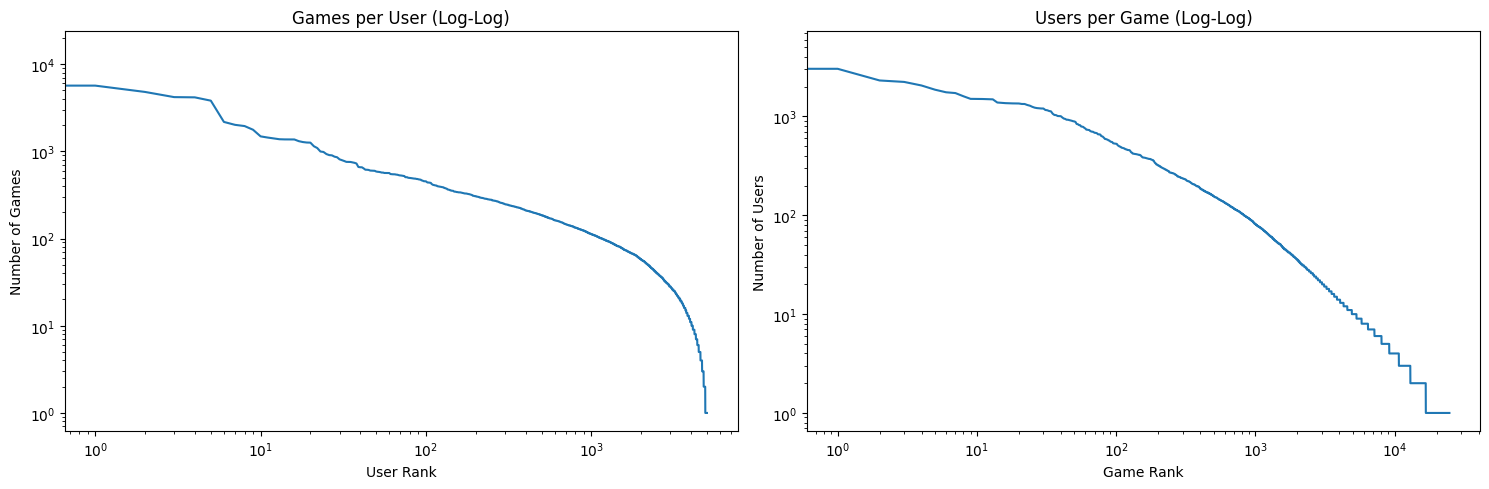

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

user_games = pd.read_csv('data/user_games_target.csv')

games_per_user = user_games.groupby('steamid').size().sort_values(ascending=False).values
users_per_game = user_games.groupby('appid').size().sort_values(ascending=False).values

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(games_per_user)
axes[0].set_yscale('log')
axes[0].set_xscale('log')
axes[0].set_title('Games per User (Log-Log)')
axes[0].set_xlabel('User Rank')
axes[0].set_ylabel('Number of Games')

axes[1].plot(users_per_game)
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_title('Users per Game (Log-Log)')
axes[1].set_xlabel('Game Rank')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

### Оценка разреженности матрицы (Sparsity)

Считаем процент заполненных ячеек в матрице взаимодействий user-item.
Ключевая метрика для выбора архитектуры модели. Если заполненность сильно меньше 1% (что типично для RecSys), классические матричные разложения (SVD) будут работать плохо без регуляризации. Высокая разреженность — сигнал к тому, что нам обязательно потребуются контентные признаки (жанры, ОС, цены) и гибридные модели (LightFM, нейросети), чтобы справляться с проблемой холодного старта.

*Выводы :*
*   Заполненность матрицы составляет: 0.996502 %

In [18]:
n_users = user_games['steamid'].nunique()
n_items = user_games['appid'].nunique()
n_interactions = len(user_games)

filled_percent = (n_interactions / (n_users * n_items)) * 100
sparsity = 1.0 - (n_interactions / (n_users * n_items))

print(f"Users: {n_users}")
print(f"Items: {n_items}")
print(f"Interactions: {n_interactions}")
print(f"Matrix Filled: {filled_percent:.6f}%")
print(f"Sparsity: {sparsity:.6f}")

Users: 5000
Items: 24700
Interactions: 431965
Matrix Filled: 0.349769%
Sparsity: 0.996502


### Анализ Playtime: Распределение по времени и ОС

Смотрим на гистограмму общего времени в игре и распределение суммарного времени по операционным системам.
**Практическая польза:** 
1. Логарифмированное распределение времени покажет, есть ли аномалии (например, массовые нули или боты с миллионами часов).
2. Данные по ОС — отличный кандидат в признаки (фичи) для модели. Если паттерны игры на Mac/Linux сильно отличаются (например, там играют только в инди-стратегии), это поможет модели точнее персонализировать выдачу для пользователей этих ОС.

*Выводы по графикам ):*
*   Распределение общего времени: куча холодных юзеров 
*   Доминирующая ОС и роль остальных ОС: windows

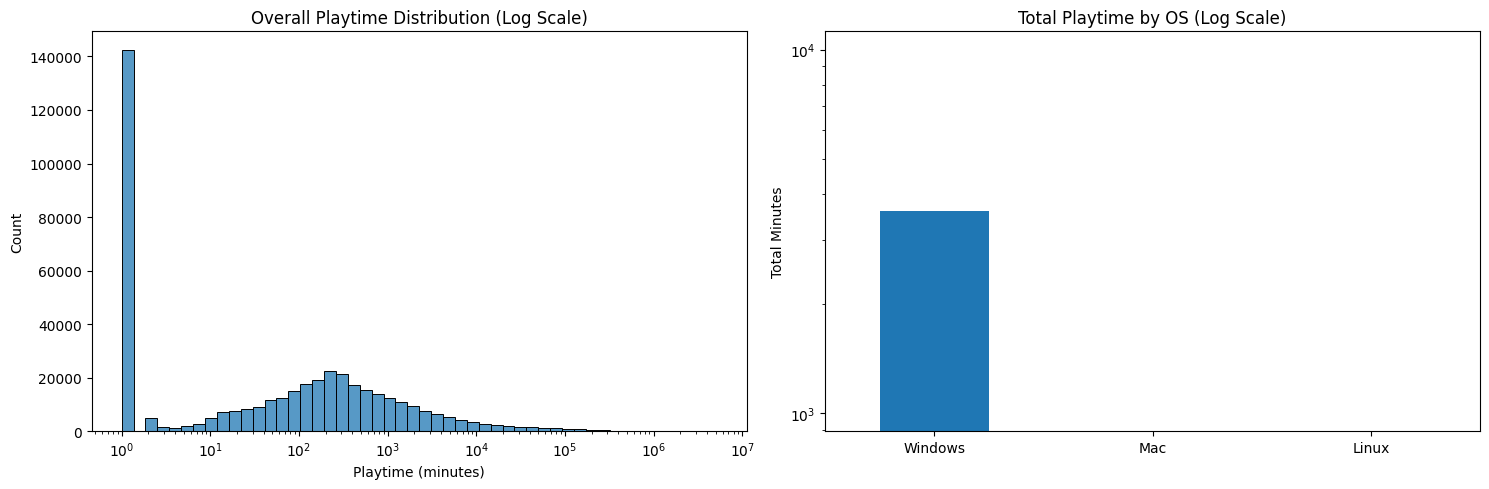

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(user_games['playtime_forever'] + 1, log_scale=True, bins=50, ax=axes[0])
axes[0].set_title('Overall Playtime Distribution (Log Scale)')
axes[0].set_xlabel('Playtime (minutes)')

os_cols = ['playtime_windows_forever', 'playtime_mac_forever', 'playtime_linux_forever']
os_playtime = user_games[os_cols].sum()
os_playtime.plot(kind='bar', ax=axes[1], color=['#1f77b4', '#7f7f7f', '#ff7f0e'])
axes[1].set_title('Total Playtime by OS (Log Scale)')
axes[1].set_ylabel('Total Minutes')
axes[1].set_yscale('log')
axes[1].set_xticklabels(['Windows', 'Mac', 'Linux'], rotation=0)

plt.tight_layout()
plt.show()

### Анализ Playtime: Время в игре в разрезе жанров

 Джоиним данные пользователей с метаданными игр, разворачиваем список жанров (explode) и строим боксплоты времени для Топ-10 жанров.
**Практическая польза:** 
Мы проверяем гипотезу: зависит ли время сессии/жизни в игре от ее жанра. Если медианы на боксплотах (и разбросы) сильно отличаются (например, RPG > Action > Casual), значит жанр — это критически важная фича. Модель должна понимать, что 50 часов в жанре Casual — это хардкор, а 50 часов в MMO — это только старт.

*Выводы по графикам:*
*   медианы отличаются, занчит жанр - полезная фича

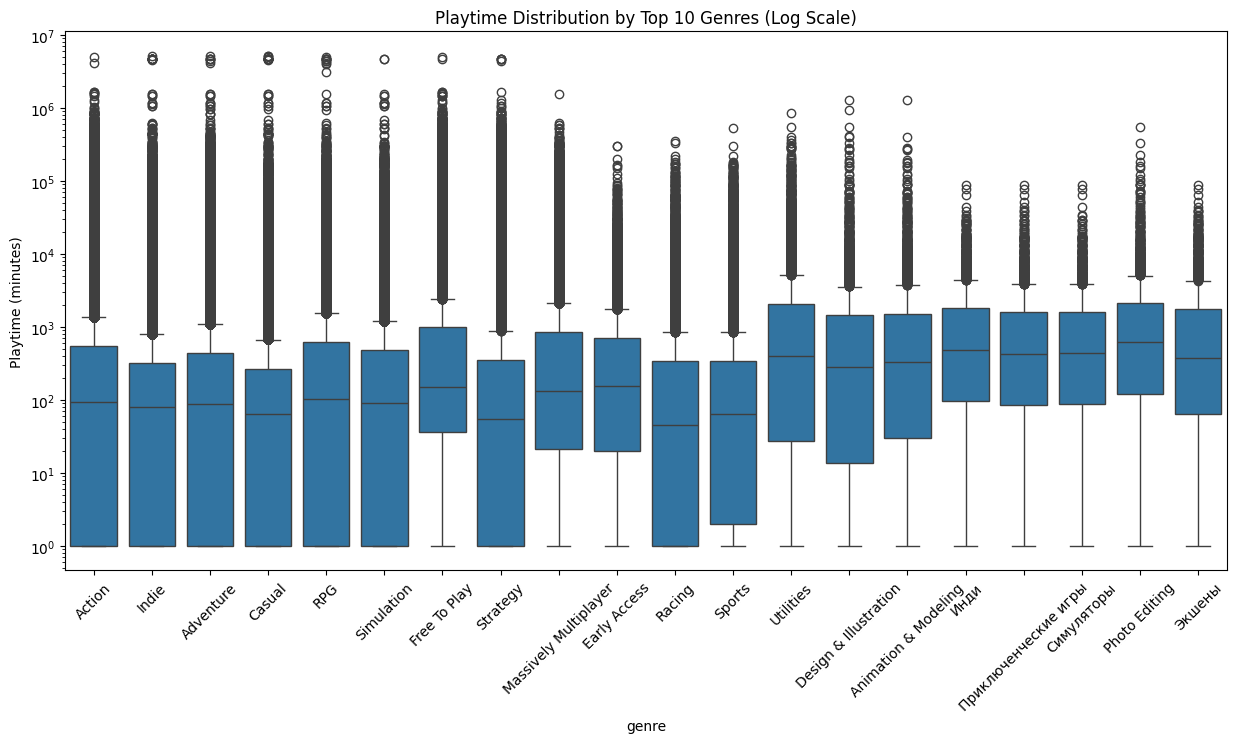

In [20]:
import ast

games_df = pd.read_csv('data/game_details.csv')

def parse_genres(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

games_df['genres_list'] = games_df['genres'].apply(parse_genres)
games_exploded = games_df[['appid', 'genres_list']].explode('genres_list').dropna()
games_exploded.rename(columns={'genres_list': 'genre'}, inplace=True)

merged_df = user_games[['appid', 'playtime_forever']].merge(games_exploded, on='appid')

top_genres = merged_df['genre'].value_counts().head(20).index
filtered_df = merged_df[merged_df['genre'].isin(top_genres)].copy()

filtered_df['playtime_forever'] = filtered_df['playtime_forever'] + 1 

plt.figure(figsize=(15, 7))
sns.boxplot(x='genre', y='playtime_forever', data=filtered_df, order=top_genres)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title('Playtime Distribution by Top 10 Genres (Log Scale)')
plt.ylabel('Playtime (minutes)')
plt.show()

/var/folders/dw/k7m_br6s4hz846j1dx_hjjz40000gq/T/ipykernel_76558/3595060468.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_games, x='month', palette='viridis')


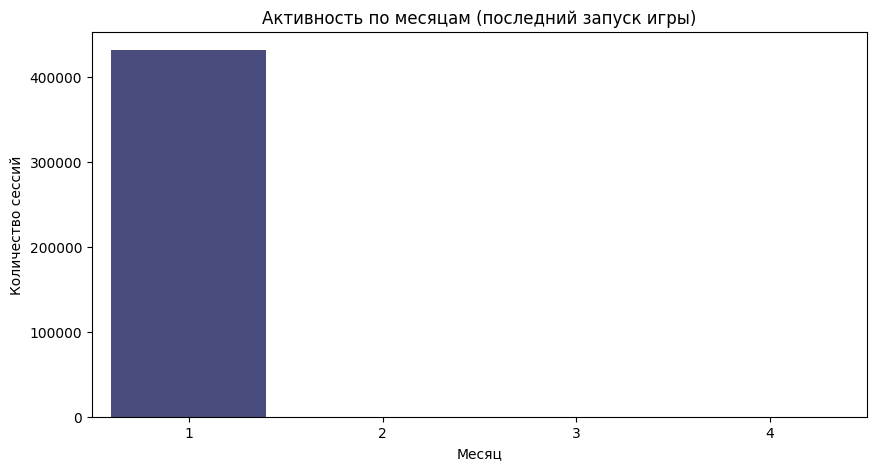

In [21]:
# 1. Временная динамика (Сезонность по месяцам)
user_games['last_played_date'] = pd.to_datetime(user_games['rtime_last_played'], unit='s')
user_games['month'] = user_games['last_played_date'].dt.month

plt.figure(figsize=(10, 5))
sns.countplot(data=user_games, x='month', palette='viridis')
plt.title('Активность по месяцам (последний запуск игры)')
plt.xlabel('Месяц')
plt.ylabel('Количество сессий')
plt.show()

/var/folders/dw/k7m_br6s4hz846j1dx_hjjz40000gq/T/ipykernel_76558/3195104577.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette="viridis")


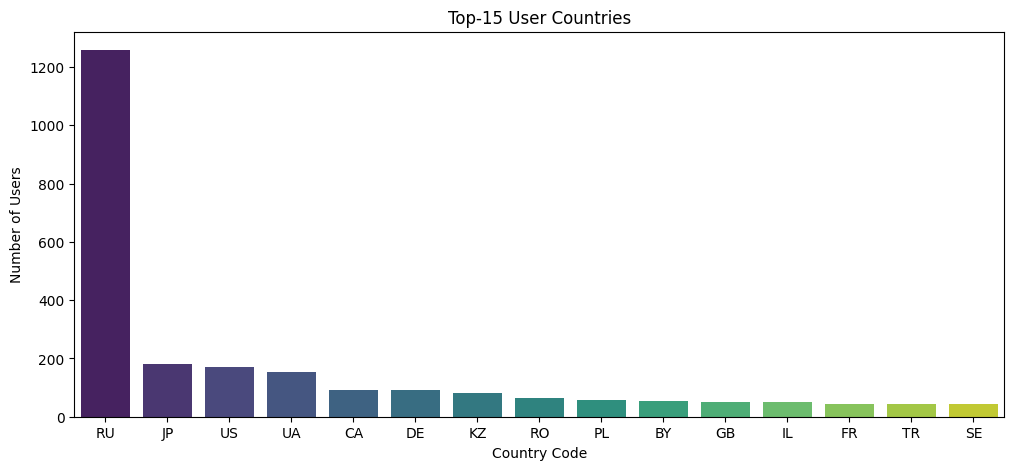

In [23]:
users_df = pd.read_csv('data/unique_users.csv')
plt.figure(figsize=(12, 5))
top_countries = users_df['loccountrycode'].value_counts().head(15)
sns.barplot(x=top_countries.index, y=top_countries.values, palette="viridis")
plt.title('Top-15 User Countries')
plt.ylabel('Number of Users')
plt.xlabel('Country Code')
plt.show()

### Влияние модели распространения: Бесплатные (F2P) vs Платные игры

Сравниваем количество бесплатных и платных игр, а также медианное время, проведенное в них.
У бесплатных игр (Free-to-Play) нулевой порог входа. Люди часто добавляют их, запускают на 10 минут и бросают. У платных игр порог входа высокий (нужно купить), поэтому игроки склонны "отбивать" потраченные деньги и играть дольше. Колонка `is_free` — мощнейший сигнал для алгоритма.

/var/folders/dw/k7m_br6s4hz846j1dx_hjjz40000gq/T/ipykernel_76558/799711366.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_free', y='playtime_log', data=df_free, ax=axes[1], palette="Set2")


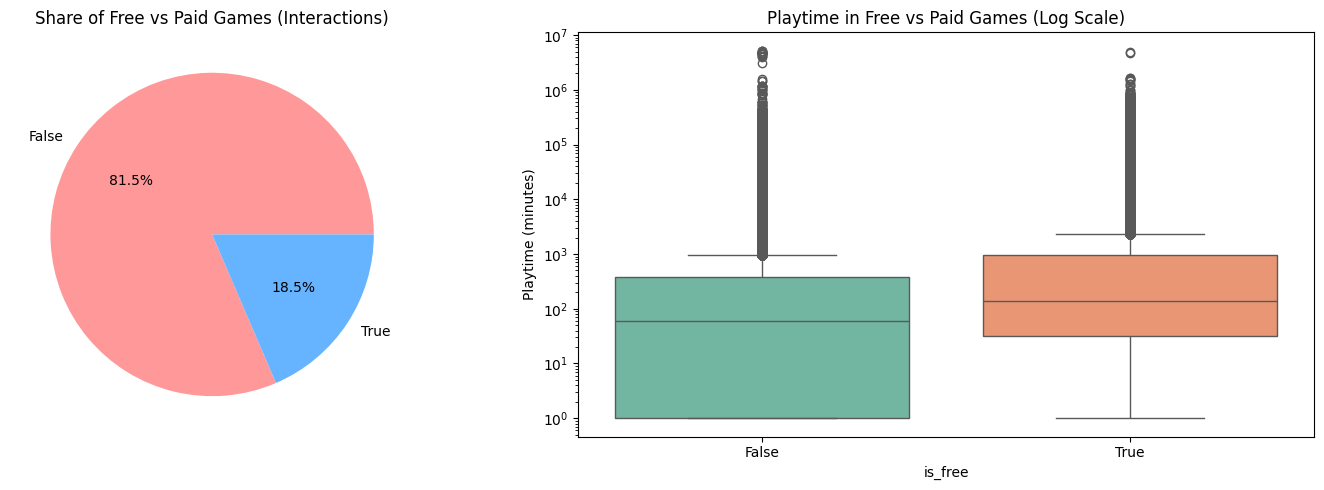

In [25]:
df_free = user_games[['appid', 'playtime_forever']].merge(games_df[['appid', 'is_free']], on='appid', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Доля бесплатных игр в библиотеках пользователей
df_free['is_free'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], colors=['#ff9999','#66b3ff'])
axes[0].set_title('Share of Free vs Paid Games (Interactions)')
axes[0].set_ylabel('')

# График 2: Время в игре в зависимости от платности
df_free['playtime_log'] = df_free['playtime_forever'] + 1 
sns.boxplot(x='is_free', y='playtime_log', data=df_free, ax=axes[1], palette="Set2")
axes[1].set_yscale('log')
axes[1].set_title('Playtime in Free vs Paid Games (Log Scale)')
axes[1].set_ylabel('Playtime (minutes)')

plt.tight_layout()
plt.show()

Считаем долю пользователей, у которых в библиотеке меньше 5 игр.
**Практическая польза:** 
Алгоритмам коллаборативной фильтрации  нужна история, чтобы понять вкусы человека. Если у юзера 1-3 игры, ML-модель выдаст случайный мусор. Таким пользователям (Cold-Start) лучше показывать отдельную полку: "Самое популярное в вашем регионе" или "Лидеры продаж". Этот график покажет, какой % нашей аудитории нуждается в такой "заглушке".

*Выводы по графику:*
*   Процент "холодных" пользователей (< 5 игр) составляет: 8.7% %
*   Решение: будем использовать эвристику топ-популярных

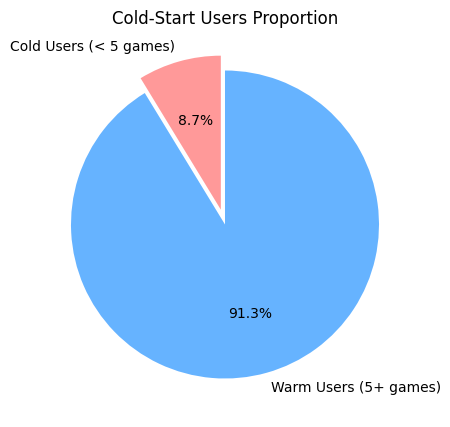

Total users: 5000
Users with < 5 games: 436


In [26]:
user_interaction_counts = user_games.groupby('steamid').size()

cold_users = (user_interaction_counts < 5).sum()
warm_users = (user_interaction_counts >= 5).sum()

plt.figure(figsize=(7, 5))
plt.pie([cold_users, warm_users], labels=['Cold Users (< 5 games)', 'Warm Users (5+ games)'], 
        autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.1, 0))
plt.title('Cold-Start Users Proportion')
plt.show()

print(f"Total users: {len(user_interaction_counts)}")
print(f"Users with < 5 games: {cold_users}")

### Пересечение жанров 
Строим тепловую карту (Heatmap) совместной встречаемости топ-15 жанров.
Многие игры имеют по 3-5 тегов/жанров. Если мы видим сильную корреляцию (например, "Action" почти всегда пересекается с "Adventure" или "RPG"), мы можем сократить размерность данных или объединить эти жанры в один кластер. Э

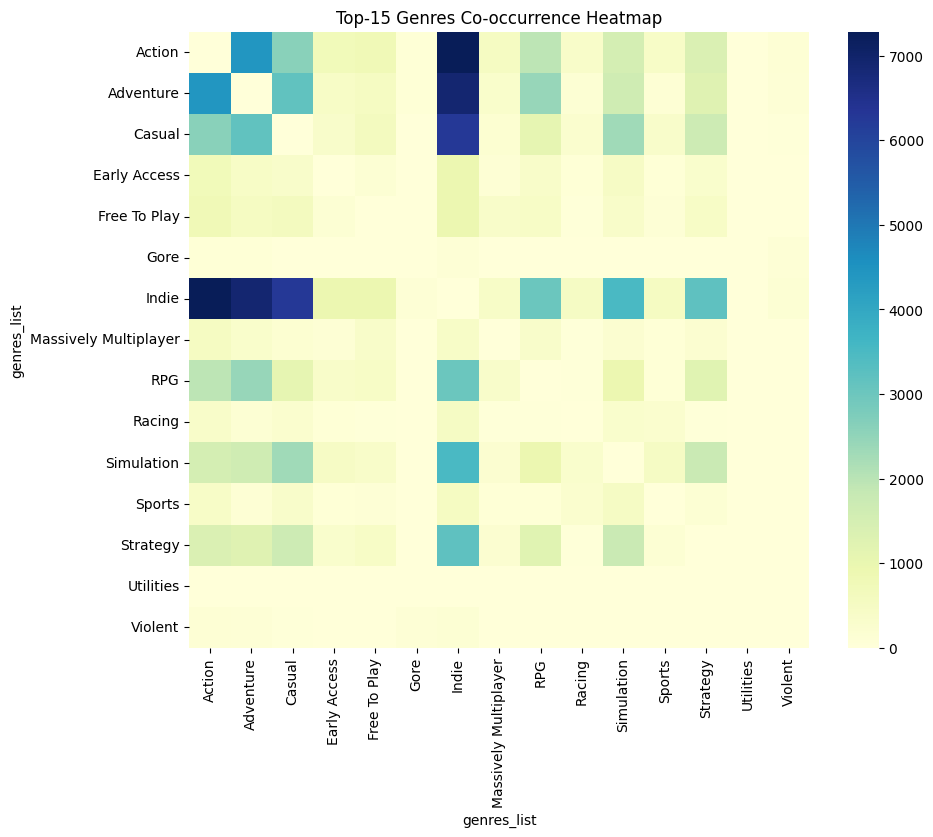

In [27]:
import ast
def parse_list(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

games_df['genres_list'] = games_df['genres'].apply(parse_list)

genres_exploded = games_df[['appid', 'genres_list']].explode('genres_list').dropna()
top_15_genres = genres_exploded['genres_list'].value_counts().head(15).index
filtered_genres = genres_exploded[genres_exploded['genres_list'].isin(top_15_genres)]
crosstab = pd.crosstab(filtered_genres['appid'], filtered_genres['genres_list'])

co_occurrence = crosstab.T.dot(crosstab)
np.fill_diagonal(co_occurrence.values, 0)

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, cmap='YlGnBu', annot=False, fmt='d')
plt.title('Top-15 Genres Co-occurrence Heatmap')
plt.show()

### Жизненный цикл игры 
Считаем возраст игры (в годах) на текущий момент и смотрим, как меняется медианное время в игре и количество игроков в зависимости от "старости" проекта.

Игры "стареют". Если старые игры играются в разы меньше новых, нам нужно будет добавить в формулу рекомендации штраф за возраст игры (Time Decay Penalty).


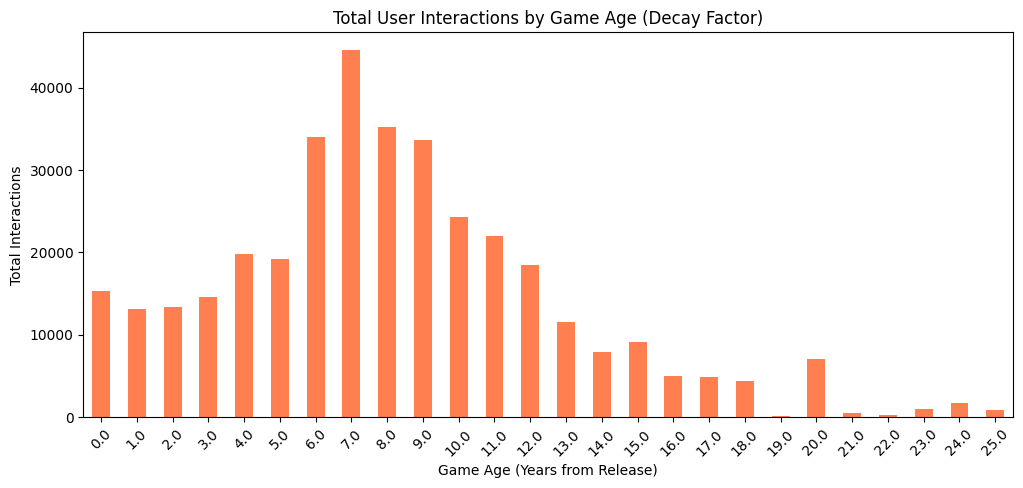

In [28]:
games_df['release_year'] = games_df['release_date'].str.extract(r'(\d{4})').astype(float)
games_df['age_years'] = 2024 - games_df['release_year'] 

valid_games = games_df[(games_df['age_years'] >= 0) & (games_df['age_years'] <= 25)]
df_decay = valid_games[['appid', 'age_years']].merge(user_games[['appid']], on='appid')

interactions_by_age = df_decay.groupby('age_years').size()

plt.figure(figsize=(12, 5))
interactions_by_age.plot(kind='bar', color='coral')
plt.title('Total User Interactions by Game Age (Decay Factor)')
plt.xlabel('Game Age (Years from Release)')
plt.ylabel('Total Interactions')
plt.xticks(rotation=45)
plt.show()

### Анализ пропусков в данных 


/var/folders/dw/k7m_br6s4hz846j1dx_hjjz40000gq/T/ipykernel_76558/2653248601.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percentages.values, y=missing_percentages.index, palette='Reds_r')


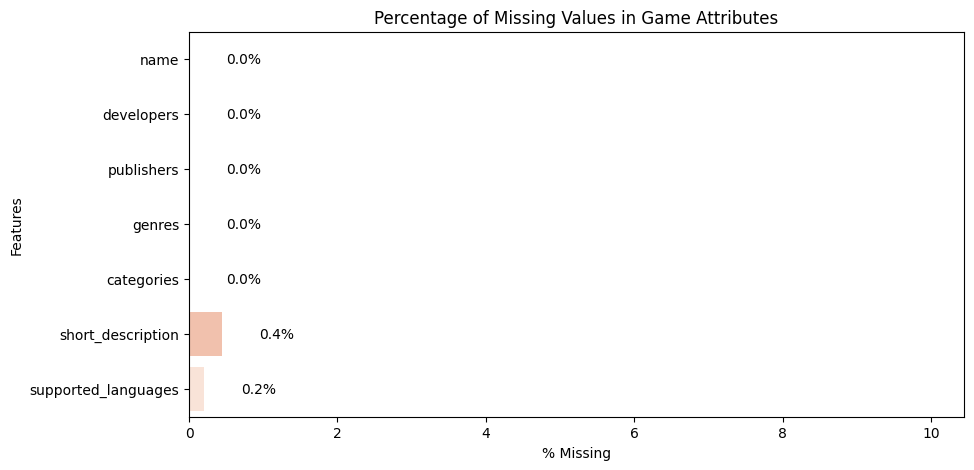

In [29]:
content_cols = ['name', 'developers', 'publishers', 'genres', 'categories', 'short_description', 'supported_languages']

missing_percentages = games_df[content_cols].isnull().mean() * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_percentages.values, y=missing_percentages.index, palette='Reds_r')
plt.title('Percentage of Missing Values in Game Attributes')
plt.xlabel('% Missing')
plt.ylabel('Features')

for index, value in enumerate(missing_percentages.values):
    plt.text(value + 0.5, index, f"{value:.1f}%", va='center')

plt.xlim(0, max(missing_percentages.values) + 10 if max(missing_percentages.values) > 0 else 10)
plt.show()

### Итоговые выводы после EDA и план действий

**1. Разреженность (0.35%) и Long Tail (Log-Log)**
*   **Вывод:** Матрица экстремально пустая, 80% онлайна сидит в топ-20% игр.
*   **Действие:** Чистые матрицы (SVD/ALS) не справятся, берем гибридную модель (LightFM/CatBoost) и отсекаем из трейна "мертвые" игры (< 5 игроков).

**2. Playtime: Общее распределение и Жанры**
*   **Вывод:** Есть огромный пик околонулевых сессий, при этом в RPG/Стратегиях играют кратно дольше, чем в Action.
*   **Действие:** Сырое время использовать нельзя — мы уже перевели его в перцентили внутри каждой игры (таргет 1-5). Жанр используем как ключевую фичу.

**3. Демография (Топ-15 стран)**
*   **Вывод:** Наблюдается колоссальный перекос в сторону одного региона (RU). 
*   **Действие:** Страну (`loccountrycode`) обязательно подаем в модель как категориальный признак, чтобы учитывать локальные тренды.

**4. Платные vs Бесплатные (is_free)**
*   **Вывод:** В платные игры играют заметно дольше (пользователи "отбивают" затраты).
*   **Действие:** Флаг `is_free` станет мощным бинарным предиктором качества вовлеченности.

**5. Холодный старт (Cold-Start Users)**
*   **Вывод:** Почти 9% пользователей имеют < 5 игр — для них алгоритмы машинного обучения выдадут случайный шум.
*   **Действие:** Пишем отдельную fallback-функцию (эвристику): для таких юзеров просто рекомендуем Топ-популярных игр.

**6. Пересечение жанров (Heatmap)**
*   **Вывод:** Жанры Indie, Action и Adventure образуют сильные связки и постоянно встречаются вместе.
*   **Действие:** Применяем Multi-Hot Encoding для жанров, чтобы гибридная модель выучила эти паттерны совместимости.

**7. Жизненный цикл (Decay Factor)**
*   **Вывод:** Пик популярности в нашей базе приходится на проекты 6-9 летней давности, игры старше 12-15 лет стремительно "умирают".
*   **Действие:** Добавляем числовую фичу `age_years` (возраст игры), чтобы алгоритм учитывал устаревание контента.